In [1]:
from transformers import AutoModelForCausalLM
import torch
model = AutoModelForCausalLM.from_pretrained("./models/gemma-3-4b-it", torch_dtype=torch.float16)
for name, p in model.named_parameters():
    if torch.isnan(p).any() or torch.isinf(p).any():
        print("坏了:", name)


d:\terry\Documents\Repositories\Gemma.c\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 883/883 [00:07<00:00, 125.45it/s]


layer 0: mean -0.00, std 0.36
layer 1: mean -0.00, std 0.40
layer 2: mean +0.00, std 0.49
layer 3: mean +0.00, std 0.51
layer 4: mean +0.02, std 1.12
layer 5: mean +0.03, std 1.77
layer 6: mean +0.04, std 2.03
layer 7: mean +0.06, std 3.09
layer 8: mean +0.08, std 4.39
layer 9: mean +0.09, std 4.83
layer 10: mean +0.13, std 6.58
layer 11: mean +0.16, std 8.29
layer 12: mean +0.19, std 9.58
layer 13: mean +0.22, std 10.91
layer 14: mean +0.22, std 11.62
layer 15: mean +0.23, std 12.03
layer 16: mean +0.25, std 13.11
layer 17: mean +0.28, std 14.41
layer 18: mean +0.31, std 15.33
layer 19: mean +0.33, std 15.81
layer 20: mean +0.32, std 16.29
layer 21: mean +0.31, std 16.64
layer 22: mean +0.34, std 17.55
layer 23: mean +0.35, std 18.00
layer 24: mean +0.39, std 18.70
layer 25: mean +0.42, std 19.94
layer 26: mean +0.43, std 21.73
layer 27: mean +0.54, std 23.80
layer 28: mean +0.53, std 25.56
layer 29: mean +0.57, std 26.68
layer 30: mean +0.57, std 26.61
layer 31: mean +0.55, std 26.94

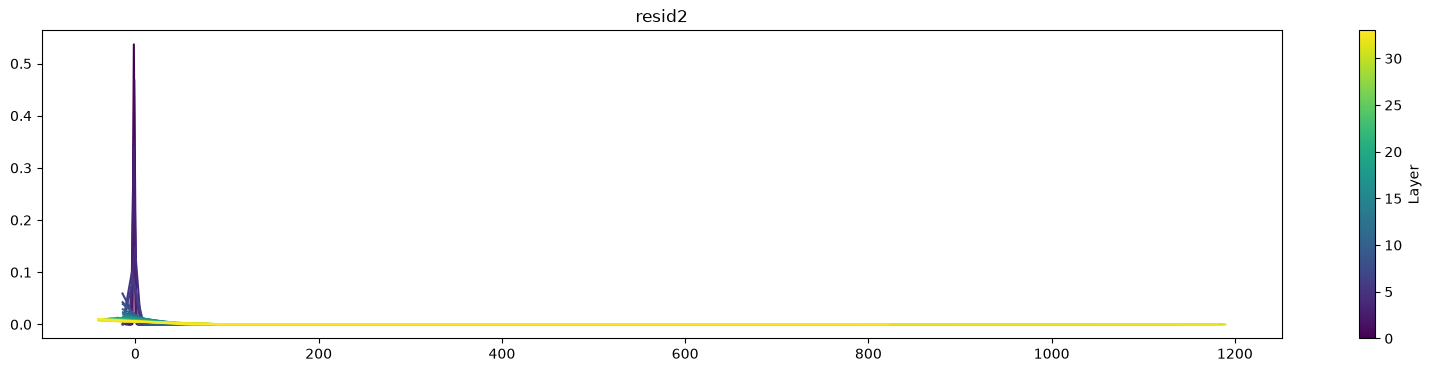

In [48]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

target = "resid2"
plt.figure(figsize=(20, 4))

layers = [layer for name, layer, pos, data in records if name == target and pos == 10]
if not layers:
    raise ValueError("No matching records found")

min_layer, max_layer = min(layers), max(layers)
norm = Normalize(vmin=min_layer, vmax=max_layer)
cmap = plt.cm.viridis

for i, (name, layer, pos, data) in enumerate(records):
    if name == target and pos == 10:
        print("layer %d: mean %+.2f, std %.2f" % (
            layer, data.mean(), data.std()
        ))
        hy, hx = np.histogram(data, density=True)
        color = cmap(norm(layer))
        plt.plot(hx[:-1], hy, color=color, label=f'layer {layer}')

sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca())
cbar.set_label('Layer')

plt.title(target)
plt.show()